Mục tiêu: tạo báo cáo cuối cùng.

Input:
```
processed/

X_train.npy
y_train.npy

X_valid.npy
y_valid.npy

X_test.npy
y_test.npy
```

Output:
```
reports/

final_data_report.md
final_data_report.json

final_class_distribution.png
pipeline_summary.png
```

In [13]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path("../")

PROCESSED_DIR = ROOT_DIR / "processed"
REPORT_DIR = ROOT_DIR / "reports"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RANDOM_STATE = 42

In [14]:
X_train = np.load(
    PROCESSED_DIR / "X_train.npy"
)

y_train = np.load(
    PROCESSED_DIR / "y_train.npy"
)

X_valid = np.load(
    PROCESSED_DIR / "X_valid.npy"
)

y_valid = np.load(
    PROCESSED_DIR / "y_valid.npy"
)

X_test = np.load(
    PROCESSED_DIR / "X_test.npy"
)

y_test = np.load(
    PROCESSED_DIR / "y_test.npy"
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

Train: (54000, 28, 28)
Valid: (6000, 28, 28)
Test : (10000, 28, 28)


In [15]:
dataset_overview = {
    "dataset_name": "MNIST",
    "num_classes": 10,
    "image_shape": list(X_train.shape[1:]),
    "train_samples": int(len(X_train)),
    "valid_samples": int(len(X_valid)),
    "test_samples": int(len(X_test))
}

dataset_overview

{'dataset_name': 'MNIST',
 'num_classes': 10,
 'image_shape': [28, 28],
 'train_samples': 54000,
 'valid_samples': 6000,
 'test_samples': 10000}

In [16]:
statistics = {
    "train_mean": float(X_train.mean()),
    "train_std": float(X_train.std()),
    "train_min": float(X_train.min()),
    "train_max": float(X_train.max())
}

statistics

{'train_mean': 0.13073687255382538,
 'train_std': 0.30819037556648254,
 'train_min': 0.0,
 'train_max': 1.0}

In [17]:
train_counts = np.bincount(
    y_train,
    minlength=10
)

valid_counts = np.bincount(
    y_valid,
    minlength=10
)

test_counts = np.bincount(
    y_test,
    minlength=10
)

distribution_df = pd.DataFrame({
    "Class": range(10),
    "Train": train_counts,
    "Validation": valid_counts,
    "Test": test_counts
})

distribution_df

,Class,Train,Validation,Test
0,0,5331,592,980
1,1,6068,674,1135
2,2,5362,596,1032
3,3,5518,613,1010
4,4,5258,584,982
5,5,4879,542,892
6,6,5326,592,958
7,7,5638,627,1028
8,8,5266,585,974
9,9,5354,595,1009


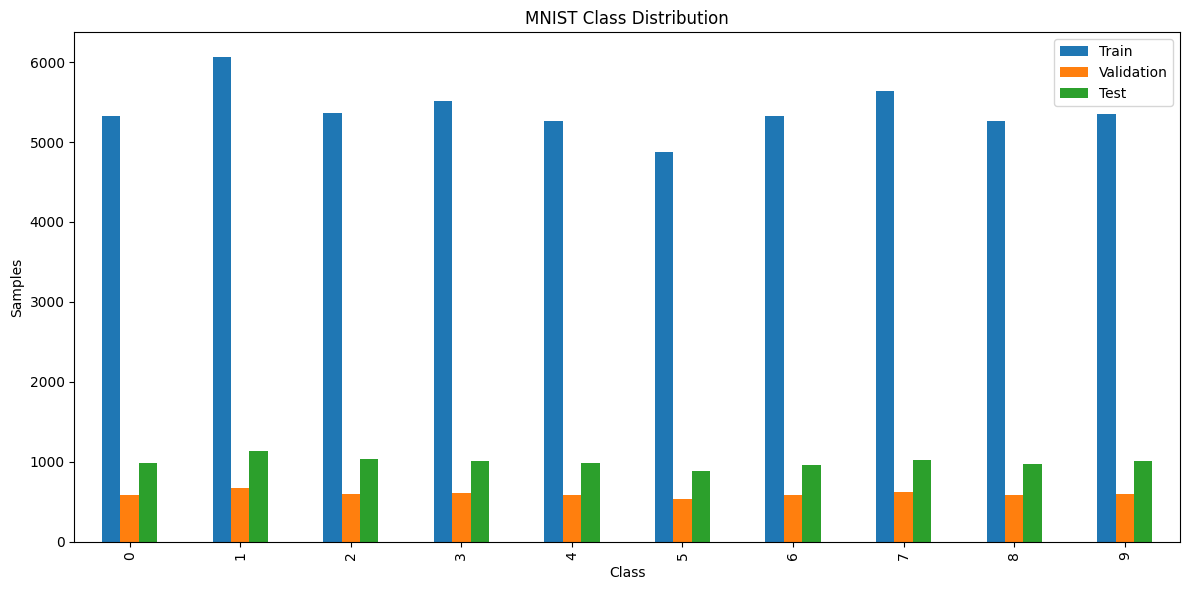

In [18]:
distribution_df.set_index(
    "Class"
).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "MNIST Class Distribution"
)

plt.ylabel(
    "Samples"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "final_class_distribution.png"
)

plt.show()

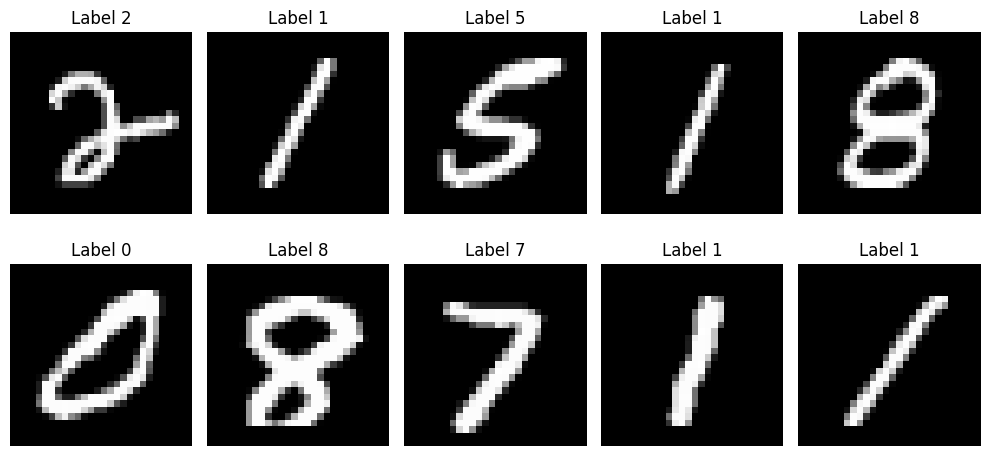

In [19]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,5)
)

for ax, idx in zip(
    axes.ravel(),
    range(10)
):

    ax.imshow(
        X_train[idx],
        cmap="gray"
    )

    ax.set_title(
        f"Label {y_train[idx]}"
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "final_samples.png"
)

plt.show()

In [20]:
pipeline_steps = [
    "Data Ingestion",
    "Data Validation",
    "Data Profiling",
    "Data Preprocessing",
    "Train Validation Split",
    "Final Dataset Report"
]

pipeline_summary = {
    "pipeline_steps": pipeline_steps,
    "pipeline_status": "SUCCESS"
}

pipeline_summary

{'pipeline_steps': ['Data Ingestion',
  'Data Validation',
  'Data Profiling',
  'Data Preprocessing',
  'Train Validation Split',
  'Final Dataset Report'],
 'pipeline_status': 'SUCCESS'}

In [21]:
quality_checks = {
    "missing_values": False,
    "shape_consistency": True,
    "label_consistency": True,
    "normalization_applied": True,
    "stratified_split": True
}

quality_checks

{'missing_values': False,
 'shape_consistency': True,
 'label_consistency': True,
 'normalization_applied': True,
 'stratified_split': True}

In [22]:
final_report = {
    "overview": dataset_overview,
    "statistics": statistics,
    "quality_checks": quality_checks,
    "pipeline_summary": pipeline_summary
}

with open(
    REPORT_DIR / "final_data_report.json",
    "w"
) as f:

    json.dump(
        final_report,
        f,
        indent=4
    )

print(
    "Saved final_data_report.json"
)

Saved final_data_report.json


In [23]:
report_md = f"""
# Final Data Report

## Dataset

- Name: MNIST
- Classes: {dataset_overview['num_classes']}
- Image Shape: {dataset_overview['image_shape']}

## Split Summary

| Split | Samples |
|--------|----------|
| Train | {dataset_overview['train_samples']} |
| Validation | {dataset_overview['valid_samples']} |
| Test | {dataset_overview['test_samples']} |

## Statistics

| Metric | Value |
|---------|---------|
| Mean | {statistics['train_mean']:.6f} |
| Std | {statistics['train_std']:.6f} |
| Min | {statistics['train_min']:.6f} |
| Max | {statistics['train_max']:.6f} |

## Quality Checks

- Missing Values: PASS
- Shape Consistency: PASS
- Label Consistency: PASS
- Normalization: PASS
- Stratified Split: PASS

## Pipeline Status

SUCCESS
"""

with open(
    REPORT_DIR /
    "final_data_report.md",
    "w",
    encoding="utf-8"
) as f:

    f.write(report_md)

print(
    "Saved final_data_report.md"
)

Saved final_data_report.md
